Team : Anna Moy & Natalie Kalukeerthie

For this project, we used the Instacart Online Grocery Shopping Dataset 2017 published on Kaggle. It was originally released by Instacart, an online grocery delivery service in the United States, to help researchers and data scientists analyze consumer purchasing patterns.

The dataset contains over 3 million grocery orders from more than 200,000 Instacart users. Each order includes detailed information on the products purchased, when they were ordered, and how often they were reordered.

This dataset is ideal for network analysis, because it naturally forms a bipartite (two-mode) network where:

- One set of nodes represents users (customers)

- The other set represents products

- Edges represent purchases (aka a user who bought a product)

 https://www.kaggle.com/datasets/psparks/instacart-market-basket-analysis?select=products.csv


We first load the Instacart data files from Kaggle. The orders file contains customer order IDs and user IDs. The order_products__prior file shows which products were in each order. The products and aisles files give product details and categories.

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

#Load the data
orders = pd.read_csv("orders.csv")
order_products = pd.read_csv("order_products__prior.csv")
products_df = pd.read_csv("products.csv")
aisles_df = pd.read_csv("aisles_instacart.csv")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Here we merge the orders and products data to connect each user with the products they’ve purchased.

In [4]:
# Merge orders with order_products to connect users and products
user_product = order_products.merge(orders[['order_id', 'user_id']], on='order_id')
user_product = user_product[['user_id', 'product_id']]
user_product.head()

,user_id,product_id
0,202279,33120
1,202279,28985
2,202279,9327
3,202279,45918
4,202279,30035


The dataset is very large (there are millions of edges). To focus on the most meaningful relationships, we use the island method to keep only strong ties:

Products purchased by ≥ 500 users

Users who bought ≥ 50 products

In [5]:
# Filter for popular products (purchased by >= 500 users)
popular_products = (
    user_product.groupby('product_id')
    .filter(lambda x: len(x) >= 500)
)

# Filter for active users (purchased >= 50 products)
active_users = (
    popular_products.groupby('user_id')
    .filter(lambda x: len(x) >= 50)
)

print("Original edges:", len(user_product))
print("Reduced edges:", len(active_users))

Original edges: 32434489
Reduced edges: 26729747


We create the bipartite graph in NetworkX with two types of nodes: users and products.

In [6]:
from networkx.algorithms import bipartite

# Prefix IDs to make user and product nodes distinct
active_users['user_id'] = 'u_' + active_users['user_id'].astype(str)
active_users['product_id'] = 'p_' + active_users['product_id'].astype(str)

# Build bipartite graph
B = nx.Graph()
B.add_nodes_from(active_users['user_id'].unique(), bipartite='users')
B.add_nodes_from(active_users['product_id'].unique(), bipartite='products')

# Add edges between users and products
edges = list(zip(active_users['user_id'], active_users['product_id']))
B.add_edges_from(edges)

# Check bipartite status again
print(f"Number of nodes: {B.number_of_nodes()}")
print(f"Number of edges: {B.number_of_edges()}")
print(f"Is the graph bipartite? {bipartite.is_bipartite(B)}")

Number of nodes: 136836
Number of edges: 9814885
Is the graph bipartite? True


We then visualize a small random subgraph to see how users and products are connected.

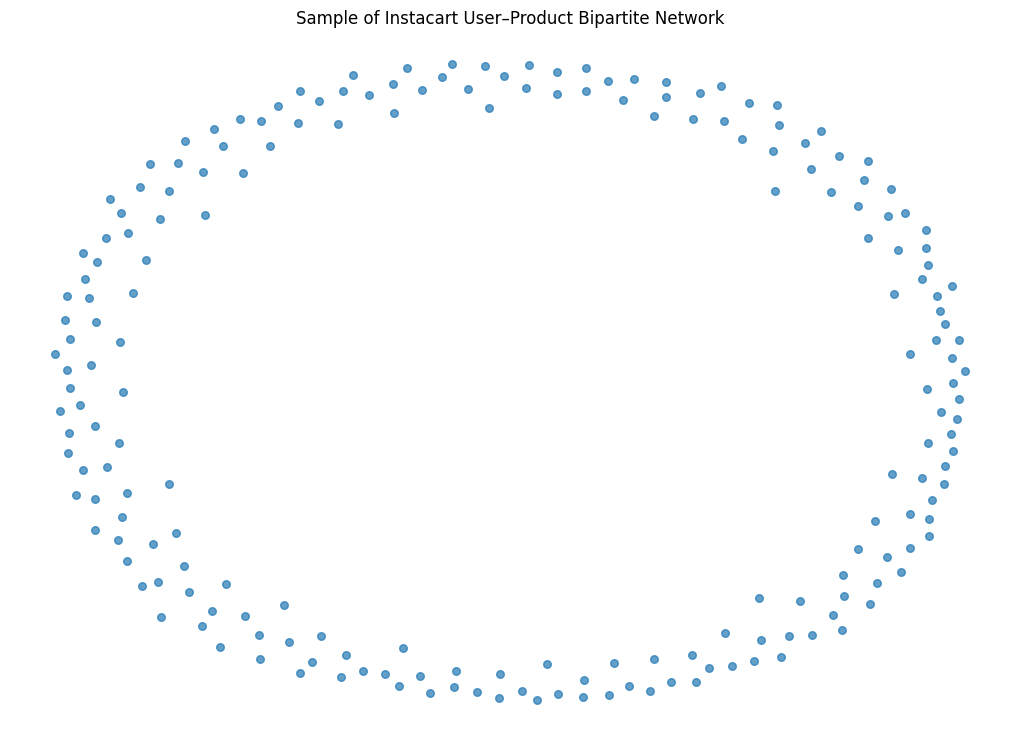

In [7]:
# Take a small random sample for visualization
sub_nodes = list(B.nodes)[:200]
subgraph = B.subgraph(sub_nodes)

plt.figure(figsize=(10,7))
nx.draw(subgraph, with_labels=False, node_size=30, alpha=0.7)
plt.title("Sample of Instacart User–Product Bipartite Network")
plt.show()

Next we calculate the degree of each node, or the number of connections per user or product, and then list the top users and products by their degree (number of connections).

In [8]:
# Separate node sets
users, products = bipartite.sets(B)

# Compute degree (number of edges per node)
user_degree = {n: B.degree(n) for n in users}
product_degree = {n: B.degree(n) for n in products}

# Convert to DataFrames for easier analysis
user_df = pd.DataFrame.from_dict(user_degree, orient='index', columns=['degree'])
product_df = pd.DataFrame.from_dict(product_degree, orient='index', columns=['degree'])

print("Top users:")
print(user_df.sort_values('degree', ascending=False).head())

print("\nTop products:")
print(product_df.sort_values('degree', ascending=False).head())

Top users:
          degree
u_182401     625
u_152144     497
u_151378     480
u_60694      462
u_106161     453

Top products:
         degree
p_24852   59248
p_13176   50505
p_21137   49895
p_21903   45599
p_47626   39745


Finally, we merge product degree information with category labels and visualize which aisles are most popular.

In [22]:
# Convert product degree dict to DataFrame
product_degree_dict = {n: B.degree(n) for n in products}  # 'products' here is the set of product nodes

product_df = pd.DataFrame.from_dict(product_degree_dict, orient='index', columns=['degree'])
product_df.index.name = 'product_node'
product_df.reset_index(inplace=True)

# Remove 'p_' prefix and convert to int to match products_df['product_id']
product_df['product_id'] = product_df['product_node'].str.replace('p_', '', regex=False).astype(float).astype(int)

# Merge with original CSV DataFrames
product_df = product_df.merge(products_df, on='product_id')  # use CSV DataFrame
product_df = product_df.merge(aisles_df, on='aisle_id')      # use CSV DataFrame

# Compute average degree per aisle
top_aisles = (
    product_df.groupby('aisle')['degree'].mean()
    .sort_values(ascending=False)
    .head(10)
)

# Plot top aisles
top_aisles.plot(kind='bar', figsize=(10,5))
plt.title("Top Aisles by Average Product Degree (Core Island)")
plt.ylabel("Average Degree")
plt.xlabel("Aisle")
plt.show()



NameError: name 'products_df' is not defined